# tcpyVPI: ERA5 vPI and GPIv, installed **from GitHub**

This notebook is the same workflow as the other ERA5 examples, but it installs
`tcpyVPI` **directly from the GitHub repository** rather than from PyPI. Use this
when you want the current state of `main` (or a specific tag) rather than waiting
for a PyPI release.

IMPORTANT: this notebook reads ERA5 data remotely via the NCAR THREDDS server.
Sometimes THREDDS throws a `NetCDF: DAP server error` when reading the data -- it
seems to be somewhat random whether/when it happens and is not due to this
notebook. If it happens, run it again.

**Cite this package:**  
Chavas, D. Sanchez, J. O., and A. Kruskie (2026). *tcpyVPI*. https://doi.org/10.5281/zenodo.19319996

[![PyPI version](https://img.shields.io/pypi/v/tcpyVPI.svg)](https://pypi.org/project/tcpyVPI/)
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19319996.svg)](https://doi.org/10.5281/zenodo.19319996)

**Author:** Dan Chavas (2026)


## 0. Install from GitHub

`pip` installs straight from the repo with the `git+https://` scheme. Tracking
`main` gives you the newest code immediately. Pinning a tag gives reproducibility,
but note a tag only exists once the corresponding GitHub Release is published.


In [11]:
# Track the latest commit on main -- works right now
!pip install -q "git+https://github.com/drchavas/tcpyVPI.git@main"

# Once the vX.Y.Z Release is published on GitHub, pin the tag instead for
# reproducibility (a tag only exists after you publish the Release):
# !pip install -q "git+https://github.com/drchavas/tcpyVPI.git@v1.1.0"

# Force a reinstall if you already have tcpyVPI from PyPI in this runtime,
# or if you are re-running after pushing new commits (pip caches by URL):
# !pip install -q --force-reinstall --no-deps "git+https://github.com/drchavas/tcpyVPI.git@main"

!pip install -q tcpyPI cartopy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Confirm it really came from GitHub, not PyPI

A PyPI install shows a bare version (`tcpyVPI==1.1.0`); a git install shows the
repository URL and the exact commit it was built from.


In [12]:
import subprocess, tcpyVPI

print("version :", tcpyVPI.__version__)
print("path    :", tcpyVPI.__file__)
print()
freeze = subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout
line = [l for l in freeze.splitlines() if l.lower().startswith("tcpyvpi")]
print("pip freeze:", line[0] if line else "(not found)")
print()
if line and "git+" in line[0]:
    print("OK - installed from GitHub")
else:
    print("WARNING - this looks like the PyPI build, not the GitHub one.")
    print("Re-run the install cell with --force-reinstall.")

version : 1.1.0
path    : /usr/local/lib/python3.13/dist-packages/tcpyVPI/__init__.py

pip freeze: tcpyVPI @ git+https://github.com/drchavas/tcpyVPI.git@97bf5cd7d348d8f4e75defcbc825b519f69ca844

OK - installed from GitHub


In [13]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tcpyVPI import (
    run_vpigpiv,
    load_era5_data,
    compute_gpiv_from_dataset,
)

### Figure saving

Every figure below is written with the package version appended to the filename,
so you can run the notebook on the old version and the new one and compare the
PNGs directly.

**Where:** into this repo's `github_tests/` folder inside Drive -- the same folder
as this notebook:

```
~/My Drive/Colab Notebooks/RESEARCH_PUBLIC/TC_vPI_GPIv_python/PythonPackage/tcpyVPI/github_tests/
```

Drive for desktop can take a minute to sync new files down. The cell prints both
the Colab path and the equivalent path on your Mac.

The custom figures use **fixed colour limits**, so the two versions are directly
comparable by eye. (The built-in `plot_vpigpiv` panels autoscale, so their
colourbars will differ between runs -- compare those with care.)


In [14]:
# --- figure saving: every file gets the package version in its name -----------
# Run this notebook once per version and the PNGs sit side by side for comparison.
import os, re, subprocess, tcpyVPI

# WHERE THE FILES GO.
# Default: straight into this repo's github_tests/ folder inside Drive, i.e.
# right alongside this notebook, at
#   ~/My Drive/Colab Notebooks/RESEARCH_PUBLIC/TC_vPI_GPIv_python/PythonPackage/tcpyVPI/github_tests/
# Colab's own /content is wiped when the runtime disconnects -- and switching
# package versions cleanly means restarting the runtime, which would delete the
# first version's figures before you could compare them.
SAVE_TO_DRIVE = True
REPO_IN_DRIVE = "Colab Notebooks/RESEARCH_PUBLIC/TC_vPI_GPIv_python/PythonPackage/tcpyVPI"

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTDIR = os.path.join("/content/drive/MyDrive", REPO_IN_DRIVE, "github_tests")
else:
    OUTDIR = "tcpyVPI_figures"          # /content only, lost on disconnect

os.makedirs(OUTDIR, exist_ok=True)

def version_tag():
    """Version string for filenames. Appends the short commit when installed
    from git, so two different commits of the same version cannot collide."""
    tag = tcpyVPI.__version__
    freeze = subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout
    line = [l for l in freeze.splitlines() if l.lower().startswith("tcpyvpi")]
    if line:
        sha = re.search(r"@([0-9a-f]{7,40})$", line[0].strip())
        if sha:
            tag = f"{tag}+g{sha.group(1)[:7]}"
    return re.sub(r"[^A-Za-z0-9._+-]", "-", tag)

VERSION_TAG = version_tag()
print("figures tagged :", VERSION_TAG)
print("SAVING INTO    :", os.path.abspath(OUTDIR))
if OUTDIR.startswith("/content/drive/MyDrive"):
    print("on your Mac    : ~/My Drive/" + OUTDIR.split("/content/drive/MyDrive/", 1)[1])
else:
    print("NOTE           : /content is erased when the runtime disconnects.")

def savefig(fig, name, dpi=140):
    """Save `fig` as <OUTDIR>/<name>_v<VERSION_TAG>.png"""
    path = os.path.join(OUTDIR, f"{name}_v{VERSION_TAG}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print("saved", os.path.basename(path))
    return path

figures will be tagged: 1.1.0+g97bf5cd
saving into           : /content/tcpyVPI_figures


## 1. One-call version

`run_vpigpiv` loads the ERA5 fields, computes everything, and draws the standard
diagnostic panels. This is the quickest way to check the install works.


Loading ERA5 monthly mean data for 2022-09...
  Loading SSTK...
  Loading SP...
  Loading T...
  Loading Q...
  Loading U...
  Loading V...
  Loading VO...


/usr/local/lib/python3.13/dist-packages/tcpyVPI/era5_loader.py:212: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([


  Data loading complete.
  Calculating Potential Intensity (PI)...
  Calculating Vertical Wind Shear (VWS)...
  Calculating Entropy Deficit (Chi)...
T600: min = 216.72251892089844 , max = 282.0955810546875
rv600: min = 9.35473963181721e-06 , max = 0.008615713566541672
sm_600: min = -85.8638635496223 , max = 255.2927700887706
sm_star_600: min = -85.72642046249604 , max = 291.6622730566628
  Calculating Capped Vorticity (eta_c)...


/usr/local/lib/python3.13/dist-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)


  Combining components for final GPIv...
GPIv: min=1.833e-24, max=0.1454, mean=0.01057
vPI: min=2.178, max=138.3, mean=84.3
PI: min=0, max=142.6, mean=47.9
ventilation_index: min=6.696e-05, max=inf, mean=inf
VWS: min=0.0005493, max=54.79, mean=15.18
Chi: min=-inf, max=inf, mean=nan
eta_c: min=-3.7e-05, max=3.7e-05, mean=3.029e-05


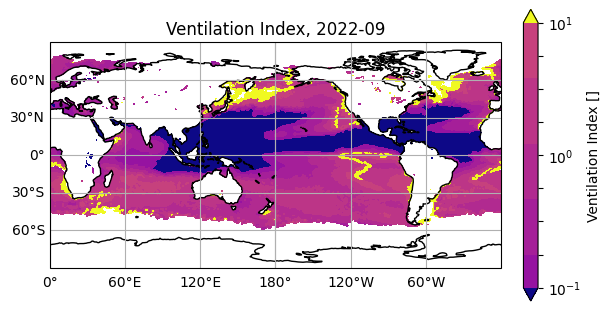

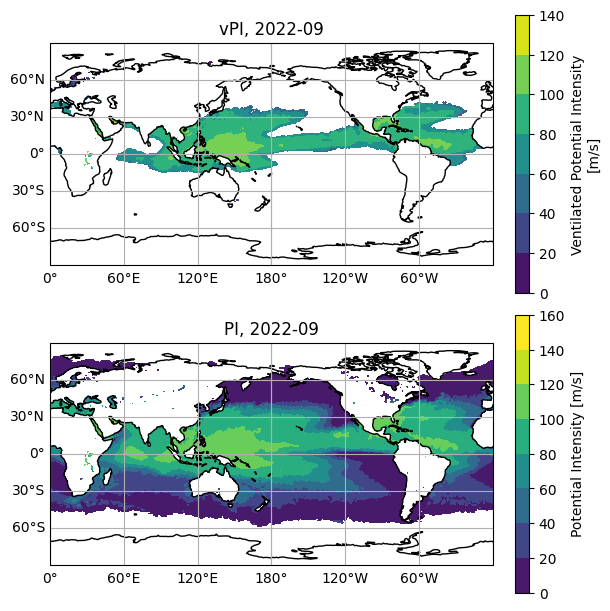

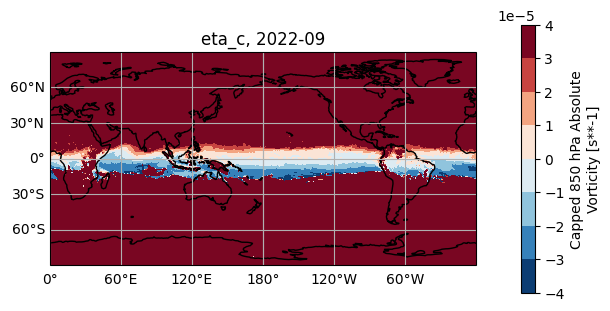

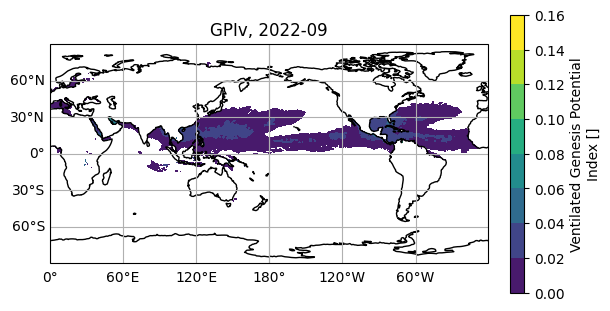


Variables computed: ['GPIv', 'vPI', 'PI', 'ventilation_index', 'VWS', 'Chi', 'eta_c']


In [15]:
year, month = 2022, 9

results = run_vpigpiv(year, month, data_source='monthly', plot=True)
print("\nVariables computed:", list(results.data_vars))

# plot_vpigpiv draws several figures internally; save whatever it opened.
import matplotlib.pyplot as plt
for n, num in enumerate(plt.get_fignums(), start=1):
    savefig(plt.figure(num), f"builtin_panel{n}_{year}{month:02d}")

## 2. Load and compute separately, then make your own plot

Splitting the two steps lets you keep the raw ERA5 fields around and plot
whatever you like.


In [ ]:
ds = load_era5_data(year, month, data_source='monthly')
results = compute_gpiv_from_dataset(ds)

results

Loading ERA5 monthly mean data for 2022-09...
  Loading SSTK...
  Loading SP...
  Loading T...


### Sample plot: potential intensity vs. ventilated potential intensity

The difference between the two panels is the whole point of the ventilated PI.
`PI` is the thermodynamic ceiling. `vPI` is what the storm can actually reach
once shear and mid-level dry air are accounted for, and it cuts off sharply to
zero where the ventilation index exceeds 0.145.


In [ ]:
proj = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(3, 1, figsize=(11, 12),
                         subplot_kw={'projection': proj},
                         constrained_layout=True)

panels = [
    ('PI',                results['PI'],                'Potential intensity  [m s$^{-1}$]',        dict(vmin=0, vmax=100, cmap='viridis')),
    ('vPI',               results['vPI'],               'Ventilated PI  [m s$^{-1}$]',              dict(vmin=0, vmax=100, cmap='viridis')),
    ('ventilation_index', results['ventilation_index'], 'Ventilation index  [-]',                   dict(vmin=0, vmax=0.3, cmap='plasma')),
]

for ax, (name, field, label, kw) in zip(axes, panels):
    p = field.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                              add_colorbar=True, cbar_kwargs={'label': label,
                                                              'shrink': 0.85},
                              **kw)
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
    ax.set_extent([-180, 180, -50, 50], crs=ccrs.PlateCarree())
    ax.set_title(f"{name}   ERA5 {year}-{month:02d}")

savefig(fig, f"PI_vPI_VI_{year}{month:02d}")
plt.show()

### The reduction from ventilation

`PI - vPI` is how much intensity the environment takes away. It is largest where
shear is strong and the mid-troposphere is dry -- the subtropics, and the eastern
sides of the basins.


In [ ]:
reduction = (results['PI'] - results['vPI']).where(results['PI'] > 0)

fig, ax = plt.subplots(figsize=(11, 4.5),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                       constrained_layout=True)
reduction.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                          vmin=0, vmax=100, cmap='magma_r',
                          cbar_kwargs={'label': 'PI $-$ vPI  [m s$^{-1}$]', 'shrink': 0.85})
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
ax.set_extent([-180, 180, -50, 50], crs=ccrs.PlateCarree())
ax.set_title(f"Intensity lost to ventilation   ERA5 {year}-{month:02d}")
savefig(fig, f"PI_minus_vPI_{year}{month:02d}")
plt.show()

## 3. Sanity check on the values

Quick check that the numbers are physically sensible. Tropical PI in September
should peak somewhere around 80-95 m/s over the warm pool, not above ~110.

Versions of tcpyVPI **up to and including v1.0.1** passed surface pressure to
`tcpyPI` in Pa instead of hPa, and specific humidity where mixing ratio was
expected, which biased PI high by roughly 25%. Both were fixed in v1.1.0. If you
see PI maxima well above 110 m/s here, check which version you installed.


In [ ]:
import csv

rows = []
for name in ['PI', 'vPI', 'ventilation_index', 'Chi', 'VWS', 'GPIv']:
    f = results[name]
    rows.append({'field': name,
                 'min':  float(f.min()),
                 'mean': float(f.mean()),
                 'max':  float(f.max())})
    print(f"{name:18s} min={rows[-1]['min']:10.4f}   "
          f"mean={rows[-1]['mean']:10.4f}   max={rows[-1]['max']:10.4f}")

# Write the same numbers to CSV so two versions can be differenced exactly,
# not just eyeballed.
stats_path = os.path.join(OUTDIR, f"stats_{year}{month:02d}_v{VERSION_TAG}.csv")
with open(stats_path, 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=['field', 'min', 'mean', 'max'])
    w.writeheader(); w.writerows(rows)
print("\nsaved", stats_path)

pi_max = float(results['PI'].max())
print()
if pi_max > 110:
    print(f"WARNING: PI max = {pi_max:.1f} m/s looks too high - are you on a pre-v1.1.0 build?")
else:
    print(f"PI max = {pi_max:.1f} m/s - in the expected range.")

## 4. Collect the output

Everything written this run, ready to compare against another version.

In [ ]:
import glob
print("Files in", os.path.abspath(OUTDIR), "\n")
for f in sorted(glob.glob(os.path.join(OUTDIR, "*"))):
    print(f"  {os.path.getsize(f)/1024:8.1f} KB  {os.path.basename(f)}")

# If you saved to /content instead of Drive, grab them before the runtime dies:
# !zip -qr tcpyVPI_figures.zip "$OUTDIR"
# from google.colab import files; files.download("tcpyVPI_figures.zip")

# Already have two versions in this directory? Difference their stats:
# import pandas as pd
# a = pd.read_csv(f"{OUTDIR}/stats_202209_v1.0.1.csv").set_index("field")
# b = pd.read_csv(f"{OUTDIR}/stats_202209_v1.1.0.csv").set_index("field")
# print((b - a) / a * 100)   # percent change, new vs old
